/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

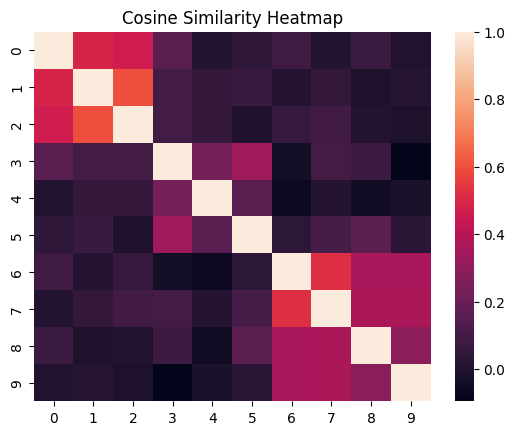

Sentence: The bowler took a wicket
Score: 0.84846324

Sentence: The batsman scored a century
Score: 0.56027603



In [1]:
!pip install sentence-transformers seaborn

from sentence_transformers import SentenceTransformer
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sentences = [
    # Cricket
    "Cricket is a popular sport in India",
    "The bowler took a wicket",
    "The batsman scored a century",

    # Cooking
    "Cooking requires patience and skill",
    "Boil water before adding rice",
    "Spices enhance the flavor of food",

    # Cybersecurity
    "Cybersecurity protects computer systems",
    "Hackers exploit system vulnerabilities",
    "Strong passwords improve security",

    # Extra (to make total 10)
    "Data breaches can cause major damage"
]

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

similarity_matrix = np.inner(embeddings, embeddings)

plt.figure()
sns.heatmap(similarity_matrix)
plt.title("Cosine Similarity Heatmap")
plt.show()

query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

scores = np.inner(query_embedding, embeddings)[0]

top2 = scores.argsort()[-2:][::-1]

for i in top2:
    print("Sentence:", sentences[i])
    print("Score:", scores[i])
    print()

